# **AdaBoost**

AdaBoost (Adaptive Boosting) adalah algoritma pembelajaran mesin yang digunakan untuk klasifikasi dan regresi. AdaBoost bekerja dengan menggabungkan beberapa model lemah menjadi satu model kuat, di mana setiap model lemah memberikan perhatian lebih pada data yang salah diklasifikasikan oleh model sebelumnya.


## **Import Libraries**


In [25]:
# Uncommeend jika belum mendownload librari yang dibutuhkan
# %pip install opencv-python
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn 
# %pip install scikit-image 
# %pip install scikit-learn
# %pip install joblib

In [27]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from skimage.feature import hog
from skimage import exposure
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

## **Data Understanding**


In [2]:
DATASET_PATH = './data'
KATEGORI = ['Plastic', 'Paper', 'Metal', 'Glass', 'Biological']
WARNA_KAT    = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

In [3]:
all_files = []
for root, _, files in os.walk(DATASET_PATH):
    for fname in files:
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_files.append(os.path.join(root, fname))
print(f"Total file gambar: {len(all_files)}")

Total file gambar: 8741


In [4]:
jumlah_data = []
for kat in KATEGORI:
    folder = os.path.join(DATASET_PATH, kat)
    if os.path.exists(folder):
        n = len([f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        jumlah_data.append(n)
        print(f"{kat:12s}: {n:4d} gambar")
    else:
        jumlah_data.append(0)
        print(f"Folder '{kat}' tidak ditemukan")
print(f"\nTotal: {sum(jumlah_data)} gambar")

Plastic     : 1984 gambar
Paper       : 1680 gambar
Metal       : 1019 gambar
Glass       : 3061 gambar
Biological  :  997 gambar

Total: 8741 gambar


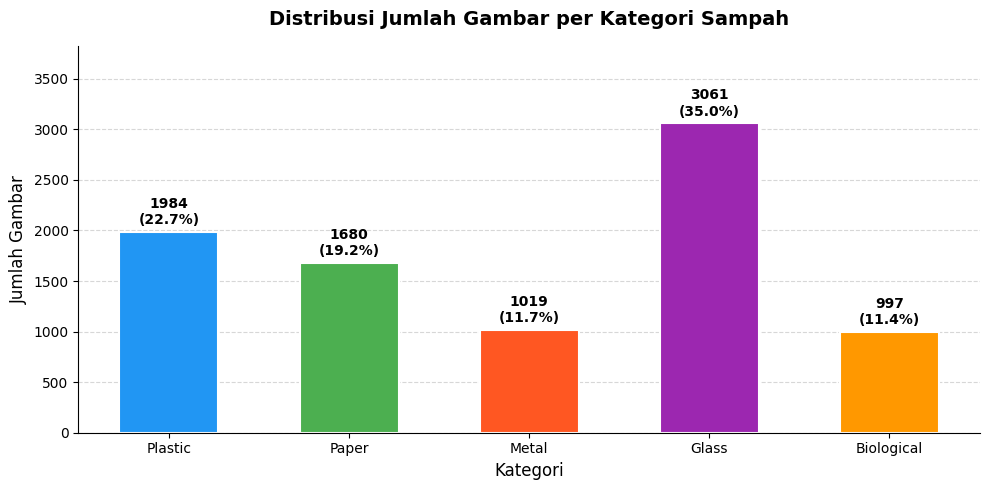

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(KATEGORI, jumlah_data, color=WARNA_KAT,
              width=0.55, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, jumlah_data):
    pct = val / sum(jumlah_data) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(jumlah_data) * 0.015,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Jumlah Gambar per Kategori Sampah',
              fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kategori', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
ax.set_ylim(0, max(jumlah_data) * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

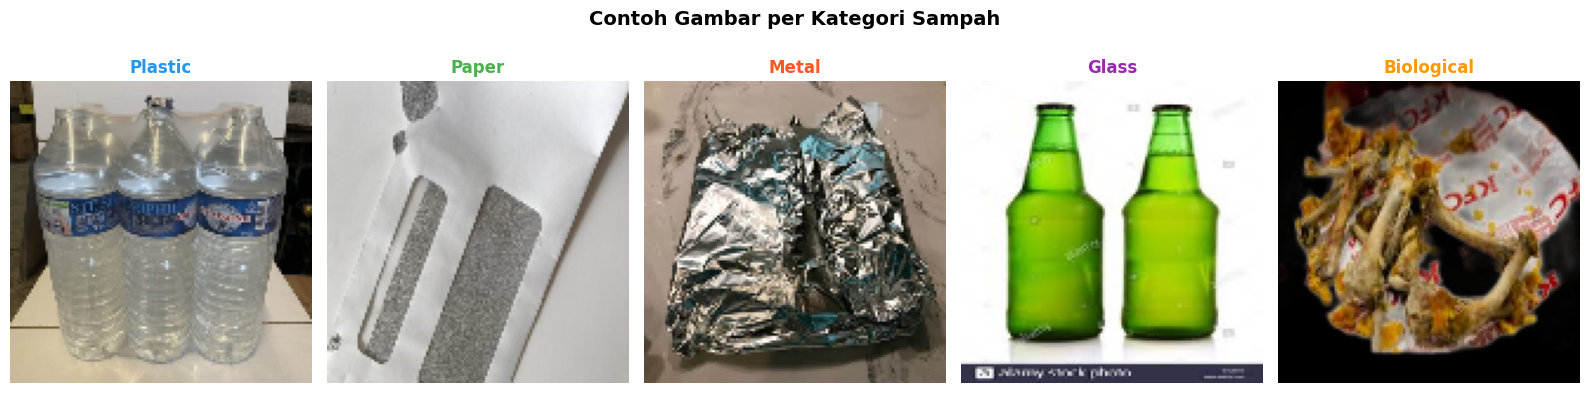

In [6]:
fig, axes = plt.subplots(1, len(KATEGORI), figsize=(16, 3.8))

for ax, kat, warna in zip(axes, KATEGORI, WARNA_KAT):
    folder = os.path.join(DATASET_PATH, kat)
    files  = sorted([f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    img    = cv2.imread(os.path.join(folder, files[0]))
    img    = cv2.resize(img, (128, 128))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(kat, fontsize=12, fontweight='bold', color=warna, pad=6)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(warna)
        spine.set_linewidth(3)

fig.suptitle('Contoh Gambar per Kategori Sampah',
              fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## **Data Preparation**


In [7]:
def extract_features(image, return_visual=False):
  total_px = image.shape[0] * image.shape[1]
  blurred  = cv2.GaussianBlur(image, (5, 5), 0)
  
  hist_r = cv2.calcHist([blurred], [2], None, [32], [0, 256]).flatten() / total_px
  hist_g = cv2.calcHist([blurred], [1], None, [32], [0, 256]).flatten() / total_px
  hist_b = cv2.calcHist([blurred], [0], None, [32], [0, 256]).flatten() / total_px
  
  # Histogram HSV
  hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
  hist_h = cv2.calcHist([hsv], [0], None, [32], [0, 256]).flatten() / total_px
  hist_s = cv2.calcHist([hsv], [1], None, [32], [0, 256]).flatten() / total_px
  hist_v = cv2.calcHist([hsv], [2], None, [32], [0, 256]).flatten() / total_px
  
  # HOG (Bentuk)
  gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
  if return_visual:
    hog_feats, hog_img = hog(
			gray, orientations=9,
			pixels_per_cell=(16, 16), cells_per_block=(2, 2),
			block_norm='L2-Hys', visualize=True
		)
    return (
			np.concatenate([hist_r, hist_g, hist_b,
											hist_h, hist_s, hist_v, hog_feats]),
			blurred,
			hog_img,
			{'hist_r': hist_r, 'hist_g': hist_g, 'hist_b': hist_b,
				'hist_h': hist_h, 'hist_s': hist_s, 'hist_v': hist_v}
		)
  else:
    hog_feats = hog(
        gray, orientations=9,
        pixels_per_cell=(16, 16), cells_per_block=(2, 2),
        block_norm='L2-Hys', visualize=False
    )
    return np.concatenate([hist_r, hist_g, hist_b,
                          hist_h, hist_s, hist_v, hog_feats])

In [8]:
folder_c  = os.path.join(DATASET_PATH, KATEGORI[0])
files_c   = sorted([f for f in os.listdir(folder_c)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

contoh_img = cv2.imread(os.path.join(folder_c, files_c[0]))
contoh_img_resized = cv2.resize(contoh_img, (128, 128))

fitur_vec, blur_img, hog_vis, hists = extract_features(
    contoh_img_resized, return_visual=True)

print(f"Kategori contoh : {KATEGORI[0]}")
print(f"Total dimensi fitur : {len(fitur_vec)}")
print(f"Histogram RGB : {len(hists['hist_r'])*3} dim  (3 × 32)")
print(f"Histogram HSV : {len(hists['hist_h'])*3} dim  (3 × 32)")
print(f"HOG : {len(fitur_vec) - 192} dim")

Kategori contoh : Plastic
Total dimensi fitur : 1956
Histogram RGB : 96 dim  (3 × 32)
Histogram HSV : 96 dim  (3 × 32)
HOG : 1764 dim


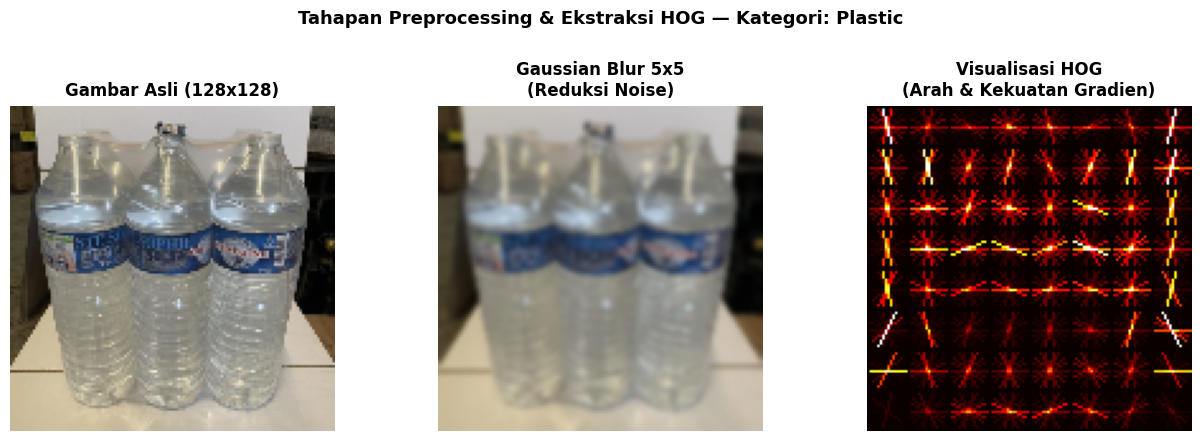

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].imshow(cv2.cvtColor(contoh_img_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Asli (128x128)', fontweight='bold', pad=8)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gaussian Blur 5x5\n(Reduksi Noise)', fontweight='bold', pad=8)
axes[1].axis('off')

hog_rescaled = exposure.rescale_intensity(hog_vis, in_range=(0, 10))
axes[2].imshow(hog_rescaled, cmap='hot')
axes[2].set_title('Visualisasi HOG\n(Arah & Kekuatan Gradien)', fontweight='bold', pad=8)
axes[2].axis('off')

fig.suptitle(f'Tahapan Preprocessing & Ekstraksi HOG — Kategori: {KATEGORI[0]}',
            fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

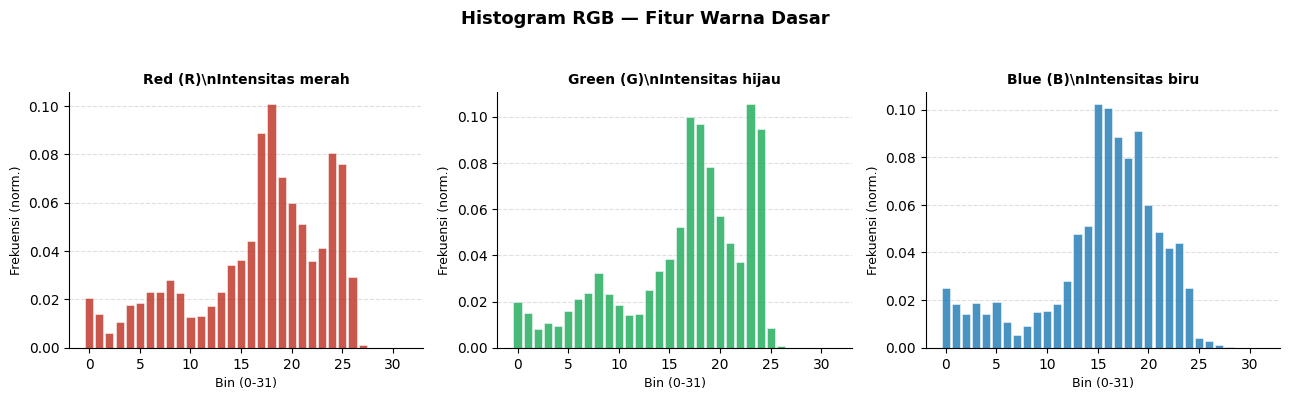

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
bins = np.arange(32)

rgb_data = [
	(hists['hist_r'], '#C0392B', 'Red (R)', 'Intensitas merah'),
	(hists['hist_g'], '#27AE60', 'Green (G)', 'Intensitas hijau'),
	(hists['hist_b'], '#2980B9', 'Blue (B)', 'Intensitas biru'),
]
for ax, (hist, color, title, sub) in zip(axes, rgb_data):
	ax.bar(bins, hist, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
	ax.set_title(f'{title}\\n{sub}', fontweight='bold', fontsize=10)
	ax.set_xlabel('Bin (0-31)', fontsize=9)
	ax.set_ylabel('Frekuensi (norm.)', fontsize=9)
	ax.yaxis.grid(True, linestyle='--', alpha=0.4)
	ax.set_axisbelow(True)
	ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Histogram RGB — Fitur Warna Dasar',
              fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

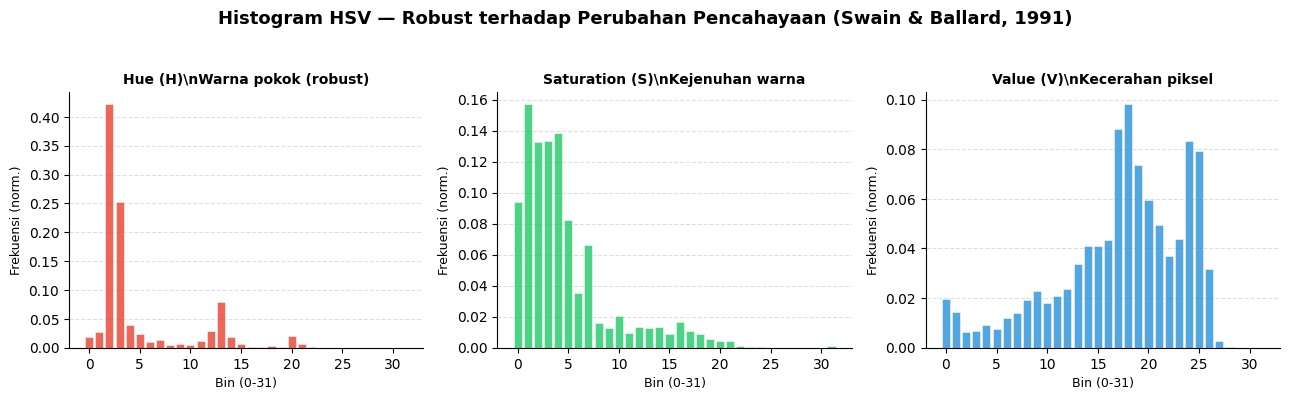

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
bins = np.arange(32)

hsv_data = [
	(hists['hist_h'], '#E74C3C', 'Hue (H)', 'Warna pokok (robust)'),
	(hists['hist_s'], '#2ECC71', 'Saturation (S)', 'Kejenuhan warna'),
	(hists['hist_v'], '#3498DB', 'Value (V)', 'Kecerahan piksel'),
]
for ax, (hist, color, title, sub) in zip(axes, hsv_data):
	ax.bar(bins, hist, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
	ax.set_title(f'{title}\\n{sub}', fontweight='bold', fontsize=10)
	ax.set_xlabel('Bin (0-31)', fontsize=9)
	ax.set_ylabel('Frekuensi (norm.)', fontsize=9)
	ax.yaxis.grid(True, linestyle='--', alpha=0.4)
	ax.set_axisbelow(True)
	ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Histogram HSV — Robust terhadap Perubahan Pencahayaan (Swain & Ballard, 1991)',
              fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## **Feature Extraction**


In [12]:
X, y = [], []

for label_idx, kat in enumerate(KATEGORI):
	folder = os.path.join(DATASET_PATH, kat)
	if not os.path.exists(folder):
		print(f"Folder '{kat}' tidak ditemukan, dilewati.")
		continue
	for fname in os.listdir(folder):
		if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
			continue
		img = cv2.imread(os.path.join(folder, fname))
		if img is None:
			continue
		img_resized = cv2.resize(img, (128, 128))
		X.append(extract_features(img_resized))
		y.append(label_idx)

In [13]:
X = np.array(X)
y = np.array(y)
print(f"Dataset siap → X: {X.shape}, y: {y.shape}")
print(f"Total sampel : {len(y)}")
print(f"Jumlah fitur : {X.shape[1]}")

Dataset siap → X: (8741, 1956), y: (8741,)
Total sampel : 8741
Jumlah fitur : 1956


## **Data Splitting**

Tiga skenario digunakan untuk mengevaluasi stabilitas generalisasi model:

| Kasus       | Training | Testing |
| ----------- | -------- | ------- |
| **Kasus 1** | 80%      | 20%     |
| **Kasus 2** | 75%      | 25%     |
| **Kasus 3** | 70%      | 30%     |


In [15]:
# Data Splitting 80:20
X_train1, X_test1, y_train1, y_test1 = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data Training : {len(X_train1):4d} sampel")
print(f"Data Testing  : {len(X_test1):4d} sampel")

Data Training : 6992 sampel
Data Testing  : 1749 sampel


In [16]:
# Data Splitting 75:25
X_train2, X_test2, y_train2, y_test2 = train_test_split(
  X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Data Training : {len(X_train2):4d} sampel")
print(f"Data Testing  : {len(X_test2):4d} sampel")

Data Training : 6555 sampel
Data Testing  : 2186 sampel


In [18]:
# Data Splitting 70:30
X_train3, X_test3, y_train3, y_test3 = train_test_split(
  X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Data Training : {len(X_train3):4d} sampel")
print(f"Data Testing  : {len(X_test3):4d} sampel")

Data Training : 6118 sampel
Data Testing  : 2623 sampel


## **Landasan Teoritis & Referensi Jurnal**

---

### 🔬 HOG — _Histogram of Oriented Gradients_

> **Dalal, N., & Triggs, B. (2005).** _Histograms of oriented gradients for human detection._
> In **IEEE Conference on Computer Vision and Pattern Recognition (CVPR)**, Vol. 1, pp. 886–893. IEEE.

HOG menghitung distribusi arah gradien lokal pada blok piksel yang tumpang tindih (_overlapping blocks_), menghasilkan representasi yang **invariant terhadap pencahayaan global** namun sensitif terhadap **tepi lokal dan bentuk**. Normalisasi L2-Hys dalam blok memberikan ketahanan tambahan terhadap bayangan dan kontras.

Relevansi terhadap klasifikasi sampah:

- **Plastik / Botol**: tepi silindris dan permukaan melengkung
- **Kaleng Logam**: tepi melingkar dan rapi
- **Kertas / Kardus**: tepi siku dan datar
- **Biologis**: tepi tidak beraturan dan asimetris

---

### 🎨 Histogram Warna (RGB & HSV)

> **Swain, M. J., & Ballard, D. H. (1991).** _Color indexing._
> **International Journal of Computer Vision**, 7(1), 11–32.

Histogram warna merupakan deskriptor yang efisien untuk pengenalan objek berbasis distribusi warna. Ruang warna **HSV** memisahkan informasi kromatik (_Hue_) dari kecerahan (_Value_), sehingga lebih robust terhadap variasi pencahayaan dibandingkan RGB.

**Mengapa keduanya digunakan?**

- **RGB**: menangkap distribusi intensitas absolut, mudah diinterpretasikan
- **HSV**: komponen Hue stabil terhadap perubahan pencahayaan; ideal untuk lingkungan pengambilan gambar yang bervariasi

> **Cheng, H., et al. (2001).** _Color image segmentation: advances and prospects._
> **Pattern Recognition**, 34(12), 2259–2281.

---

### 🌲 AdaBoost + Decision Tree sebagai Base Estimator

> **Freund, Y., & Schapire, R. E. (1997).** _A decision-theoretic generalization of on-line learning and an application to boosting._
> **Journal of Computer and System Sciences**, 55(1), 119–139.

Paper asli AdaBoost membuktikan secara teoritis bahwa kombinasi _weak learner_ — model yang performanya hanya sedikit lebih baik dari tebakan acak — dapat menghasilkan _strong learner_ dengan error arbitrarily kecil.

**Mengapa Decision Tree (_Decision Stump_, `max_depth=1`)?**

| Alasan                      | Penjelasan                                                            |
| --------------------------- | --------------------------------------------------------------------- |
| **Validitas teoritis**      | Stump terbukti memenuhi syarat weak learner (Freund & Schapire, 1997) |
| **Efisiensi komputasi**     | Satu split biner per estimator → sangat cepat dilatih                 |
| **Keragaman ensemble**      | Tiap stump fokus pada satu fitur → ensemble heterogen                 |
| **Menghindari overfitting** | Pohon sangat dangkal secara inheren ter-regularisasi                  |

> **Quinlan, J. R. (1986).** _Induction of decision trees._
> **Machine Learning**, 1(1), 81–106.

> **Schapire, R. E., & Singer, Y. (1999).** _Improved boosting algorithms using confidence-rated predictions._
> **Machine Learning**, 37(3), 297–336.

---

### 📌 Aplikasi pada Klasifikasi Sampah

> **Thung, G., & Yang, M. (2016).** _Classification of trash for recyclability status._
> CS229 Project Report, Stanford University.

> **Vo, A. H., Tran, T., & Quoc, H. T. (2019).** _Waste classification using deep learning._
> In **Proceedings of ISEE 2019**, pp. 752–756. IEEE.


## **Modeling & Parameter Tuning**


### **Pencarian `n_estimators` Optimal dengan `staged_score`**

`AdaBoostClassifier.staged_score()` mengevaluasi akurasi secara kumulatif setelah setiap estimator ditambahkan **tanpa melatih ulang** model, jauh lebih efisien dari grid search.


In [29]:
# Kasus 1 (80:20)
base_stump = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_tune = AdaBoostClassifier(
	estimator= base_stump,
	n_estimators= 200,
	learning_rate= 1.0,
	random_state= 42
)
ada_tune.fit(X_train1, y_train1)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [30]:

train_staged = list(ada_tune.staged_score(X_train1, y_train1))
test_staged  = list(ada_tune.staged_score(X_test1,  y_test1))

best_n   = int(np.argmax(test_staged)) + 1
best_acc_tune = max(test_staged)

print(f"n_estimators optimal : {best_n}")
print(f"Akurasi test terbaik : {best_acc_tune*100:.2f}%")

n_estimators optimal : 200
Akurasi test terbaik : 61.46%


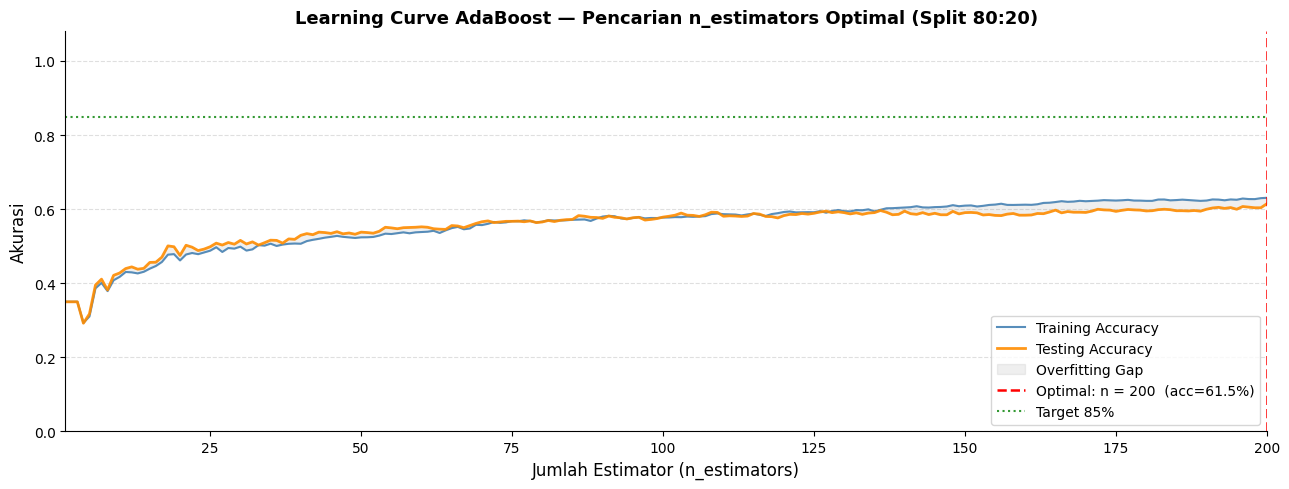

In [31]:
n_range = range(1, 201)
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(n_range, train_staged, label='Training Accuracy',
        color='steelblue', lw=1.5, alpha=0.9)
ax.plot(n_range, test_staged,  label='Testing Accuracy',
        color='darkorange', lw=2.0, alpha=0.9)
ax.fill_between(n_range, train_staged, test_staged,
                alpha=0.12, color='gray', label='Overfitting Gap')
ax.axvline(x=best_n, color='red', linestyle='--', lw=1.8,
          label=f'Optimal: n = {best_n}  (acc={best_acc_tune*100:.1f}%)')
ax.axhline(y=0.85,   color='green', linestyle=':', lw=1.5,
          label='Target 85%', alpha=0.8)

ax.set_title('Learning Curve AdaBoost — Pencarian n_estimators Optimal (Split 80:20)',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Estimator (n_estimators)', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_xlim(1, 200)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc='lower right')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Pelatihan 3 Kasus Data Splitting

Dengan `n_estimators` optimal, model dilatih pada ketiga skenario splitting.


In [33]:
SPLITS = [
	('Kasus 1 (80:20)', X_train1, X_test1, y_train1, y_test1),
	('Kasus 2 (75:25)', X_train2, X_test2, y_train2, y_test2),
	('Kasus 3 (70:30)', X_train3, X_test3, y_train3, y_test3),
]

semua_model = {}
semua_hasil = {}

bar_line = '=' * 58
print(bar_line)
print(f"  Parameter: n_estimators={best_n} | max_depth=1 | lr=1.0")
print(bar_line)

  Parameter: n_estimators=200 | max_depth=1 | lr=1.0


In [35]:
for nama, Xtr, Xte, ytr, yte in SPLITS:
	base  = DecisionTreeClassifier(max_depth=1, random_state=42)
	model = AdaBoostClassifier(
		estimator=base,
		n_estimators=best_n,
		learning_rate=1.0,
		random_state=42
	)
	model.fit(Xtr, ytr)
	yp_tr = model.predict(Xtr)
	yp_te = model.predict(Xte)

	semua_model[nama] = model
	semua_hasil[nama] = {
		'model': model,
		'y_train': ytr,
		'y_test': yte,
		'yp_train': yp_tr,
		'yp_test': yp_te,
		'train_acc': accuracy_score(ytr, yp_tr),
		'test_acc': accuracy_score(yte, yp_te),
	}
	print(f"\n{nama}")
	print(f"Training Accuracy : {accuracy_score(ytr, yp_tr)*100:.2f}%")
	print(f"Testing  Accuracy : {accuracy_score(yte, yp_te)*100:.2f}%")

print(f"\n{bar_line}")


Kasus 1 (80:20)
Training Accuracy : 63.07%
Testing  Accuracy : 61.46%

Kasus 2 (75:25)
Training Accuracy : 62.26%
Testing  Accuracy : 59.42%

Kasus 3 (70:30)
Training Accuracy : 63.04%
Testing  Accuracy : 59.74%



## **Evaluation**


In [36]:
for nama, hasil in semua_hasil.items():
	print('=' * 58)
	print(f'{nama} | Akurasi: {hasil["test_acc"]*100:.2f}%')
	print('=' * 58)
	print(classification_report(hasil['y_test'], hasil['yp_test'],
															target_names=KATEGORI))

Kasus 1 (80:20) | Akurasi: 61.46%
              precision    recall  f1-score   support

     Plastic       0.58      0.61      0.59       397
       Paper       0.61      0.70      0.65       336
       Metal       0.47      0.30      0.37       204
       Glass       0.65      0.68      0.66       612
  Biological       0.71      0.59      0.65       200

    accuracy                           0.61      1749
   macro avg       0.60      0.58      0.58      1749
weighted avg       0.61      0.61      0.61      1749

Kasus 2 (75:25) | Akurasi: 59.42%
              precision    recall  f1-score   support

     Plastic       0.58      0.56      0.57       496
       Paper       0.56      0.64      0.59       420
       Metal       0.45      0.28      0.34       255
       Glass       0.62      0.70      0.66       766
  Biological       0.69      0.60      0.64       249

    accuracy                           0.59      2186
   macro avg       0.58      0.55      0.56      2186
weighted 

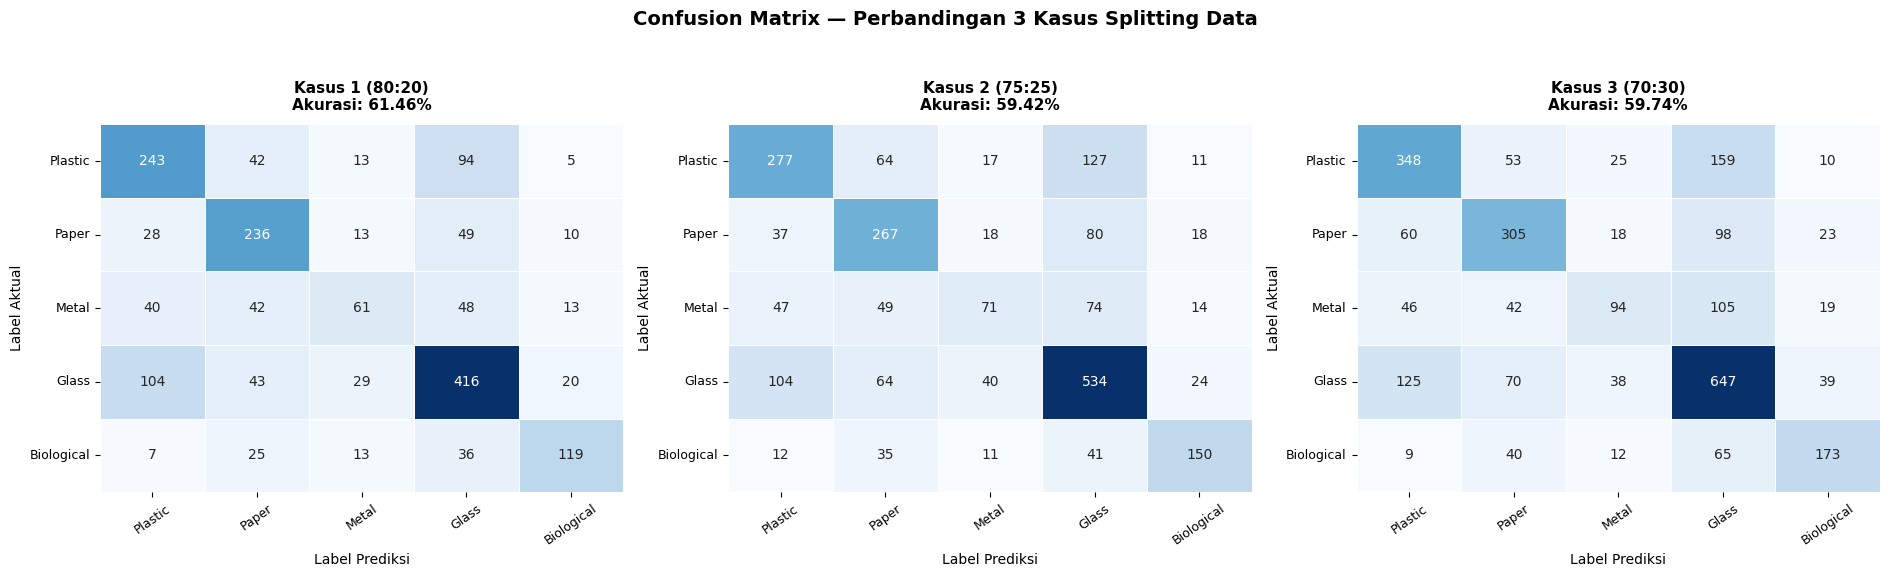

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, (nama, hasil) in zip(axes, semua_hasil.items()):
    cm = confusion_matrix(hasil['y_test'], hasil['yp_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=KATEGORI, yticklabels=KATEGORI,
                linewidths=0.5, cbar=False, annot_kws={'size': 10})
    ax.set_title(f'{nama}\nAkurasi: {hasil["test_acc"]*100:.2f}%',
                  fontweight='bold', fontsize=11, pad=10)
    ax.set_ylabel('Label Aktual', fontsize=10)
    ax.set_xlabel('Label Prediksi', fontsize=10)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

fig.suptitle('Confusion Matrix — Perbandingan 3 Kasus Splitting Data',
            fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

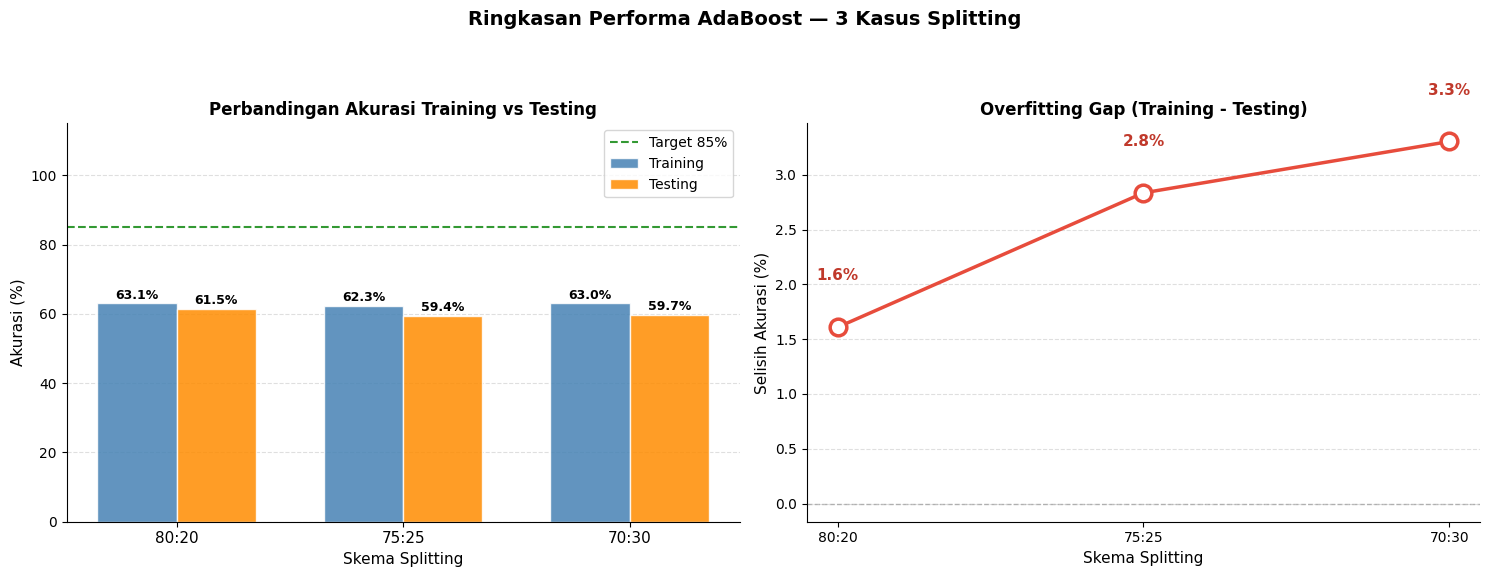

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

label_splits = ['80:20', '75:25', '70:30']
train_accs = [semua_hasil[s]['train_acc'] * 100 for s in semua_hasil]
test_accs = [semua_hasil[s]['test_acc']  * 100 for s in semua_hasil]
gap_vals = [tr - te for tr, te in zip(train_accs, test_accs)]

x = np.arange(3)
width = 0.35

b1 = axes[0].bar(x - width/2, train_accs, width,
                  label='Training', color='steelblue', alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x + width/2, test_accs,  width,
                  label='Testing',  color='darkorange', alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                  f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].axhline(y=85, color='green', linestyle='--', lw=1.5, label='Target 85%', alpha=0.8)
axes[0].set_title('Perbandingan Akurasi Training vs Testing',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Akurasi (%)', fontsize=11)
axes[0].set_xlabel('Skema Splitting', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(label_splits, fontsize=11)
axes[0].set_ylim(0, 115)
axes[0].legend(fontsize=10)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(label_splits, gap_vals, marker='o', color='#E74C3C',
              lw=2.5, markersize=12, markerfacecolor='white', markeredgewidth=2.5)
for i, (lbl, g) in enumerate(zip(label_splits, gap_vals)):
    axes[1].text(i, g + 0.4, f'{g:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='#C0392B')

axes[1].axhline(y=0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[1].set_title('Overfitting Gap (Training - Testing)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Selisih Akurasi (%)', fontsize=11)
axes[1].set_xlabel('Skema Splitting', fontsize=11)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_axisbelow(True)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Ringkasan Performa AdaBoost — 3 Kasus Splitting',
              fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

In [39]:
print(f"{'='*65}")
print(f"{'Kasus':22s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Gap':>8s}")
print(f"{'-'*65}")

best_case = None
best_acc = 0.0
for nama, hasil in semua_hasil.items():
	tr = hasil['train_acc'] * 100
	te = hasil['test_acc']  * 100
	gap = tr - te
	flag = ' ← TERBAIK' if te == max(h['test_acc'] for h in semua_hasil.values()) * 100 else ''
	print(f"{nama:22s}  {tr:>9.2f}%  {te:>9.2f}%  {gap:>7.2f}%{flag}")
	if te > best_acc:
		best_acc = te
		best_case = nama

print(f"{'='*65}")
print(f"\nModel terbaik  : {best_case}")
print(f"Test Accuracy   : {best_acc:.2f}%")

Kasus                    Train Acc    Test Acc       Gap
-----------------------------------------------------------------
Kasus 1 (80:20)             63.07%      61.46%     1.61% ← TERBAIK
Kasus 2 (75:25)             62.26%      59.42%     2.83%
Kasus 3 (70:30)             63.04%      59.74%     3.30%

Model terbaik  : Kasus 1 (80:20)
Test Accuracy   : 61.46%


## **Save Model**


In [40]:
os.makedirs('./model', exist_ok=True)
MODEL_PATH = './model/best_adaboost_model.pkl'

joblib.dump(semua_model[best_case], MODEL_PATH)

print(f"Model berhasil disimpan!")
print(f"Path : {MODEL_PATH}")
print(f"Split terbaik : {best_case}")
print(f"n_estimators : {best_n}")
print(f"Test Accuracy : {best_acc:.2f}%")

Model berhasil disimpan!
Path : ./model/best_adaboost_model.pkl
Split terbaik : Kasus 1 (80:20)
n_estimators : 200
Test Accuracy : 61.46%


## **Inference**


In [41]:
loaded_model = joblib.load(MODEL_PATH)
print(f"Tipe: {type(loaded_model).__name__}")
print(f"n_estimators: {loaded_model.n_estimators}")

Tipe: AdaBoostClassifier
n_estimators: 200


In [42]:
def predict_new_image(image_path, model, kategori=KATEGORI):
	if not os.path.exists(image_path):
		print(f"File tidak ditemukan: {image_path}")
		return None

	img = cv2.imread(image_path)
	if img is None:
		print("Format gambar tidak valid atau korup.")
		return None

	img_resized = cv2.resize(img, (128, 128))
	features = extract_features(img_resized)

	prediction = model.predict([features])
	confidence_scores = model.predict_proba([features])[0]
	predicted_class = kategori[prediction[0]]
	confidence = max(confidence_scores) * 100

	fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

	img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
	axes[0].imshow(img_rgb)
	axes[0].axis('off')
	axes[0].set_title(f'Input: {os.path.basename(image_path)}',
										fontsize=12, fontweight='bold')

	bar_colors = [WARNA_KAT[i] if i == prediction[0] else '#B0BEC5'
								for i in range(len(kategori))]
	bars = axes[1].barh(kategori, confidence_scores * 100,
											color=bar_colors, edgecolor='white', linewidth=0.8)
	axes[1].set_xlabel('Confidence (%)', fontsize=11)
	axes[1].set_xlim(0, 110)
	axes[1].set_title(f'Prediksi: {predicted_class}  ({confidence:.1f}%)',
										fontsize=12, fontweight='bold')
	axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Threshold 50%')
	axes[1].legend(fontsize=9)
	axes[1].spines[['top', 'right']].set_visible(False)

	for bar, score in zip(bars, confidence_scores):
		axes[1].text(bar.get_width() + 1,
									bar.get_y() + bar.get_height() / 2,
									f'{score*100:.1f}%', va='center', fontsize=9)

	plt.tight_layout()
	plt.show()

	print(f"\nPrediksi : {predicted_class}")
	print(f"Confidence : {confidence:.2f}%")
	print(f"\nDistribusi per Kategori:")
	for cat, score in zip(kategori, confidence_scores):
		bar_txt = '█' * int(score * 40)
		print(f"{cat:12s}: {score*100:5.1f}%  {bar_txt}")

	return predicted_class, confidence

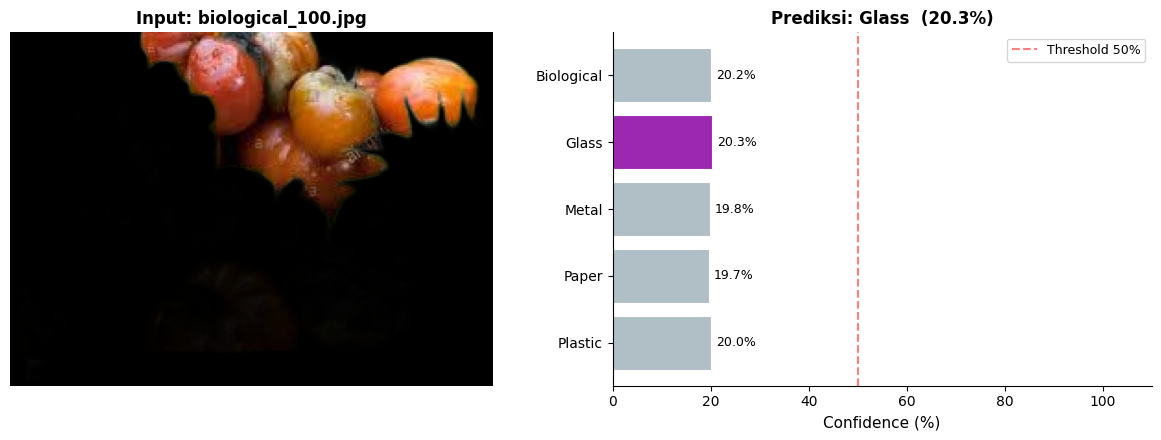


Prediksi : Glass
Confidence : 20.26%

Distribusi per Kategori:
Plastic     :  20.0%  ████████
Paper       :  19.7%  ███████
Metal       :  19.8%  ███████
Glass       :  20.3%  ████████
Biological  :  20.2%  ████████


('Glass', np.float64(20.264805297856714))

In [43]:
predict_new_image('./data/Biological/biological_100.jpg', loaded_model)